# **Week 8a | Unsupervised Learning**

KMeans and via Score Methods for clustering
Dataset : WineQT.csv (Wine Quality Dataset)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [2]:
df = pd.read_csv('WineQT.csv')

## EDA

In [3]:
df_columns = df.columns.str.lower().str.replace(' ', '_')
df.columns = df_columns
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


Text(0.5, 1.0, 'Sebaran Nilai Fixed vs Volatile pada Acidity')

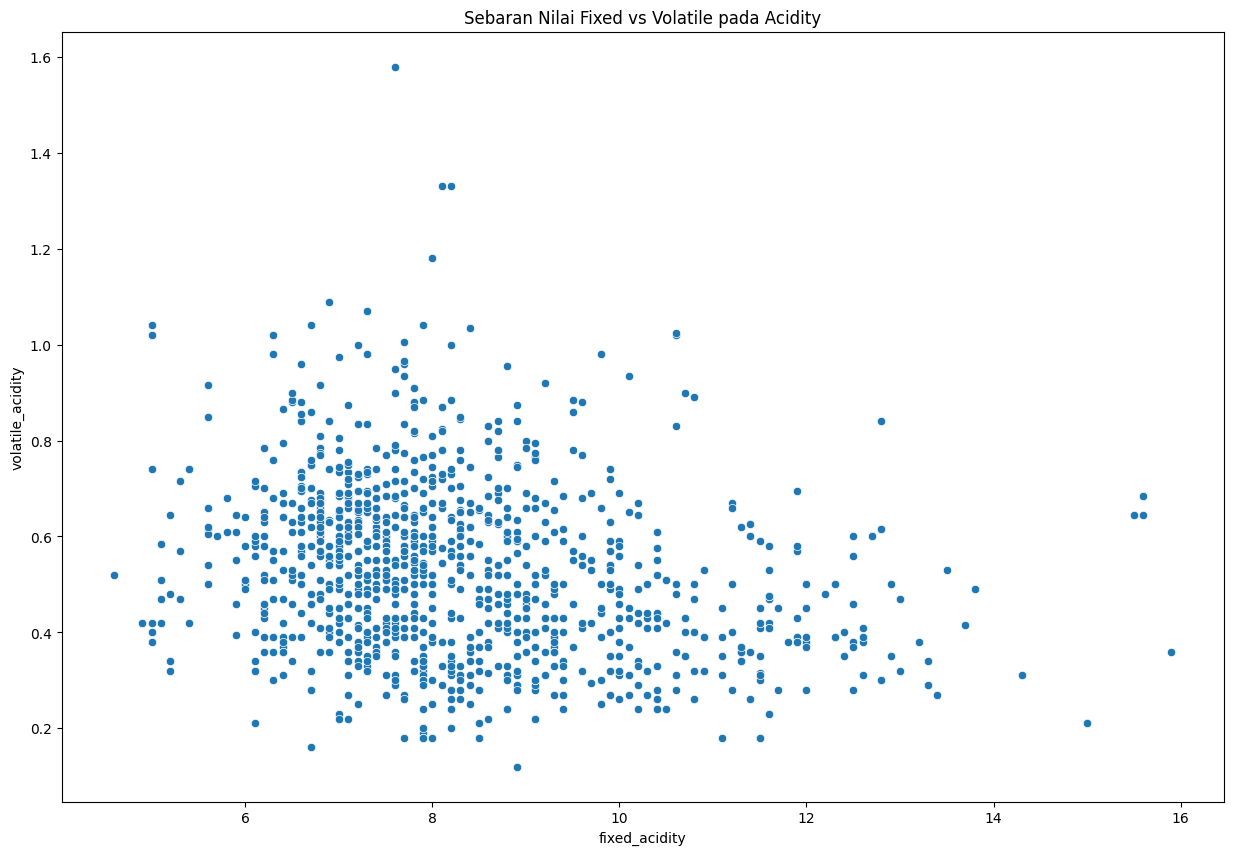

In [4]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed_acidity', y='volatile_acidity')
plt.title('Sebaran Nilai Fixed vs Volatile pada Acidity')

In [5]:
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [6]:
print(df.shape)

(1143, 13)


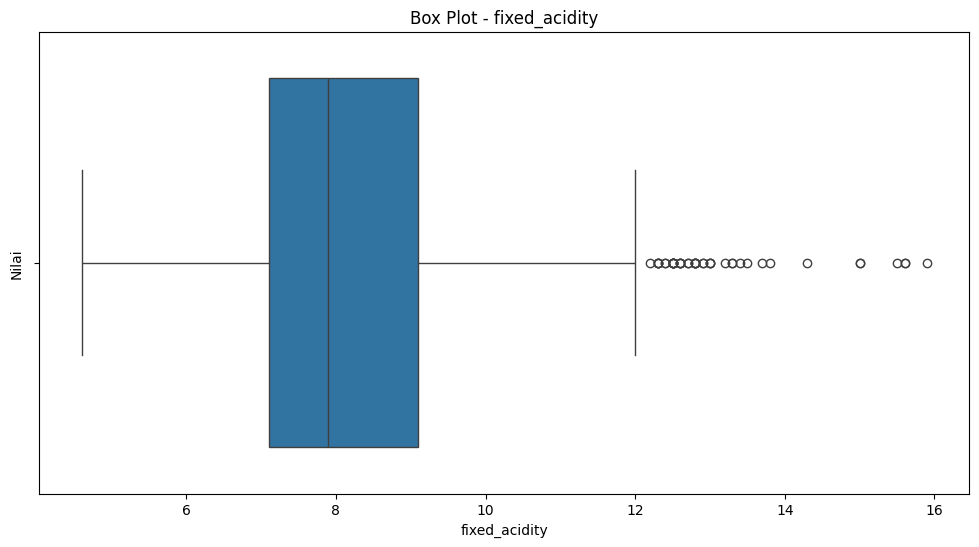

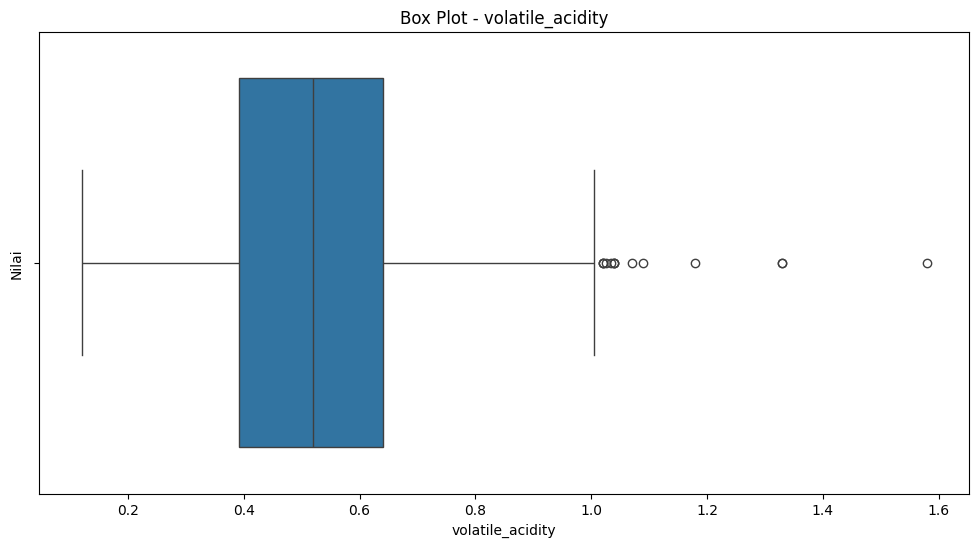

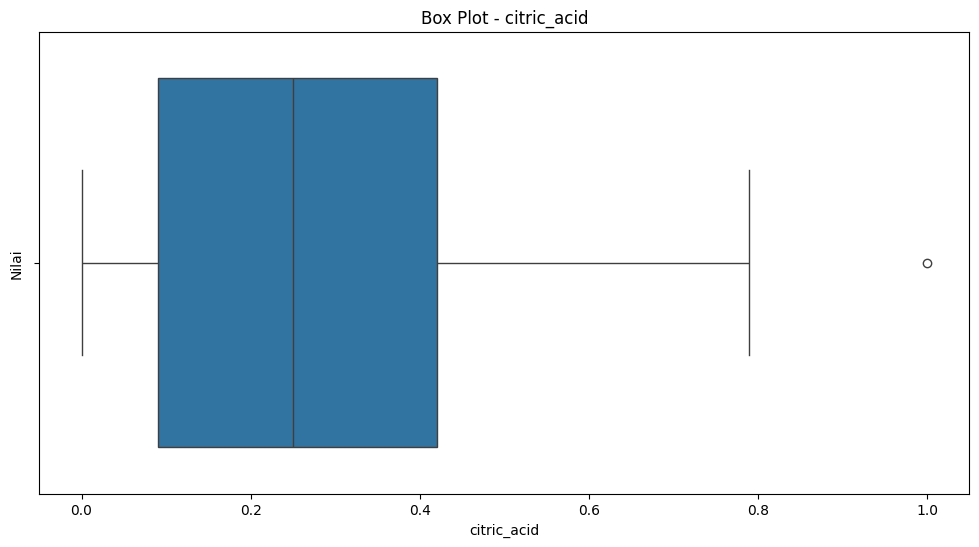

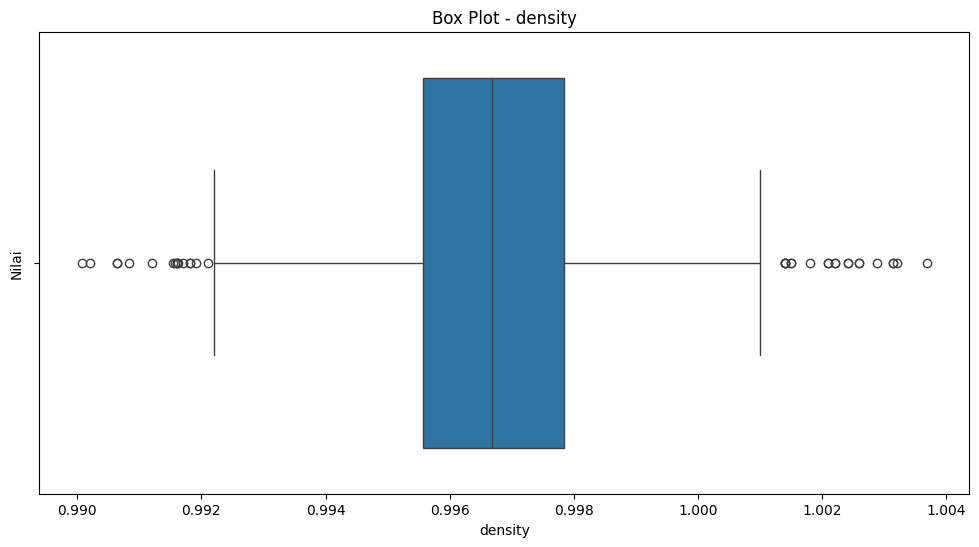

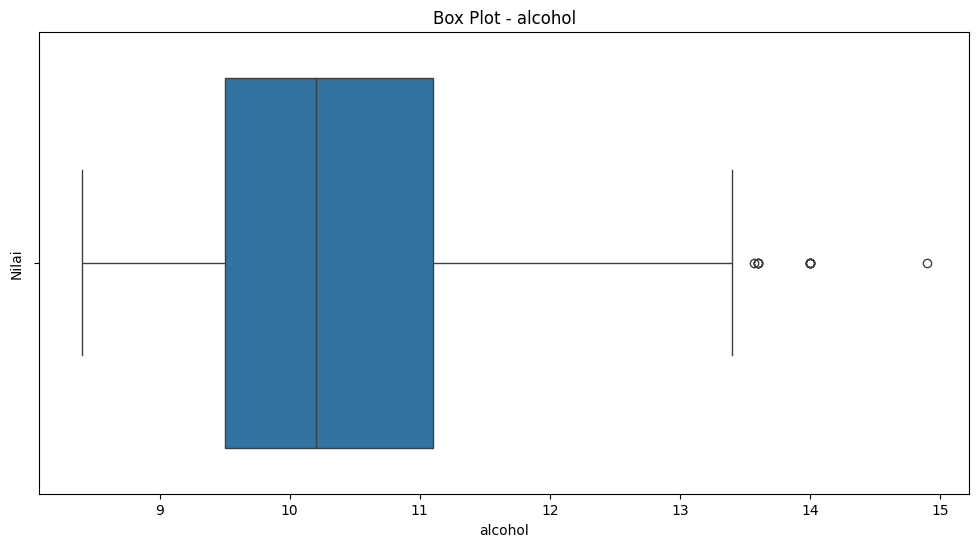

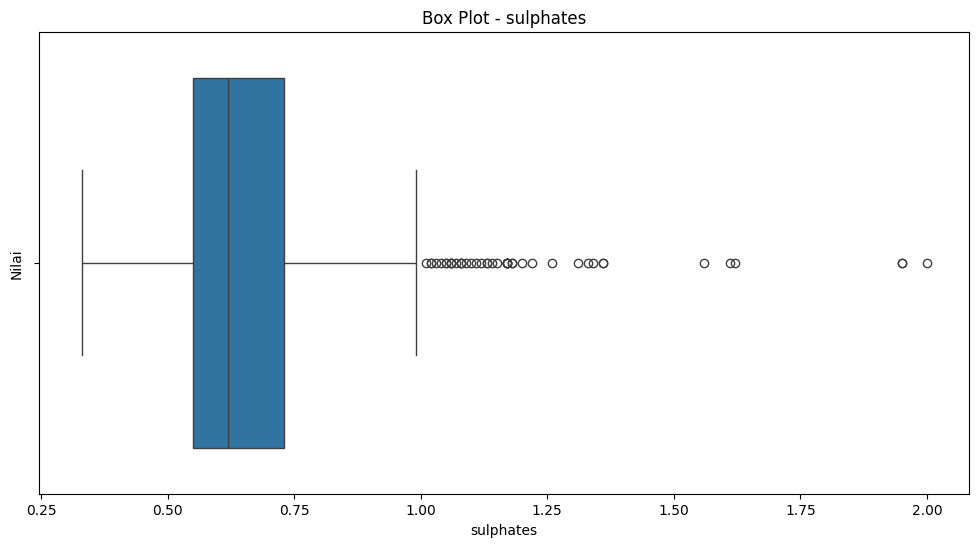

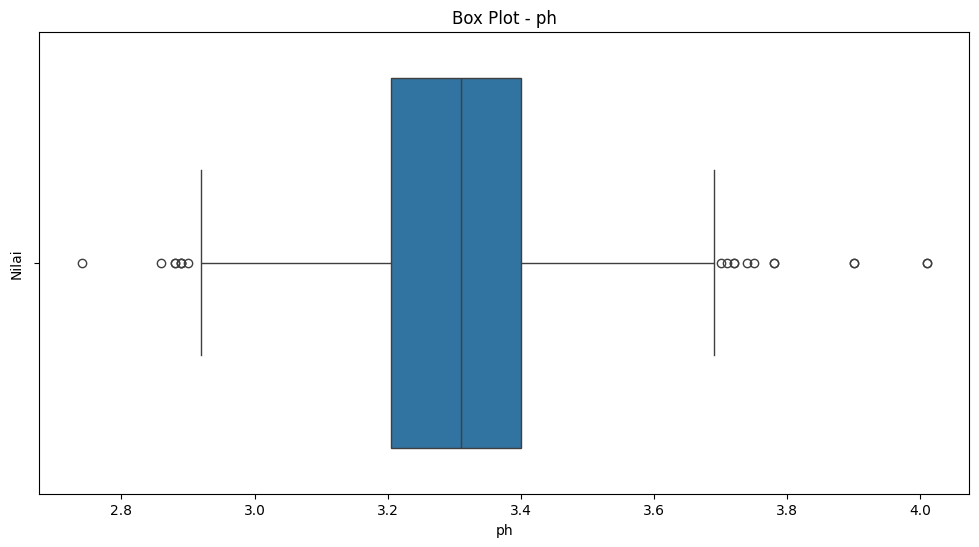

In [7]:
# Looping untuk kolom 'Fixed' dan 'Volatile'
columns = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'density', 'alcohol', 'sulphates', 'ph']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

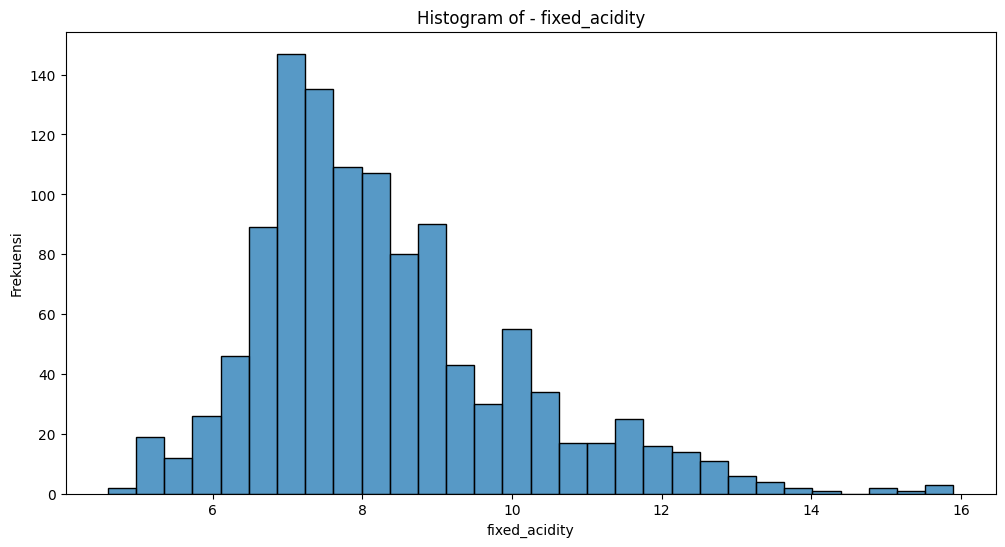

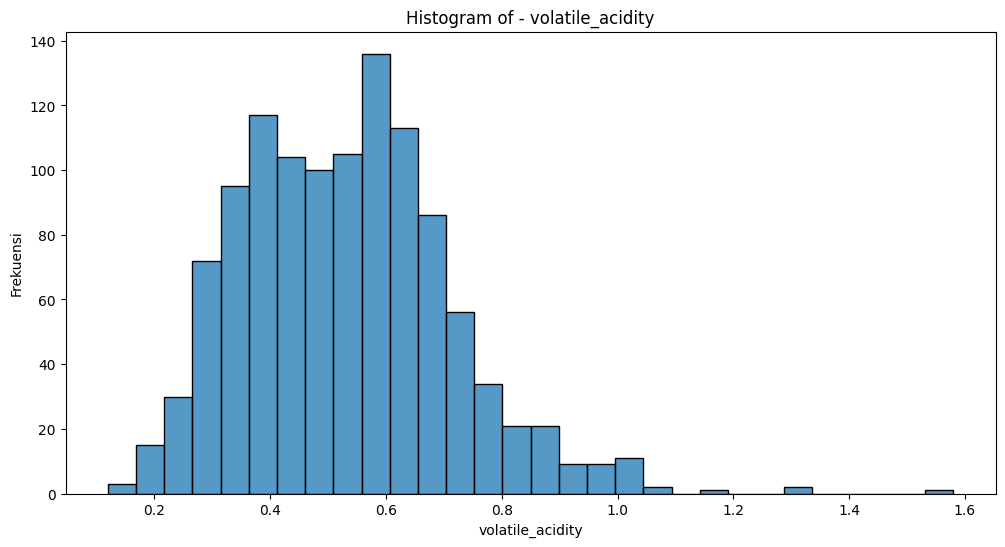

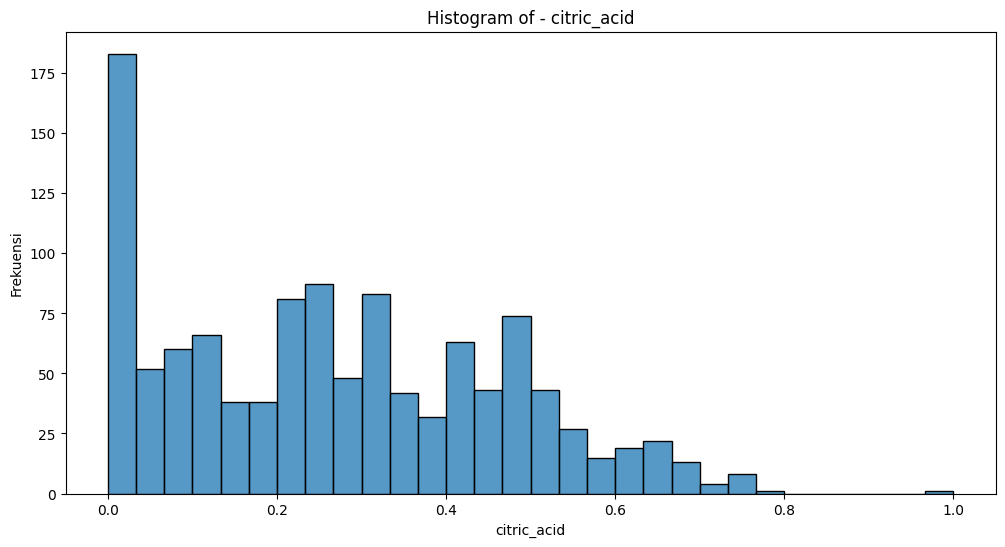

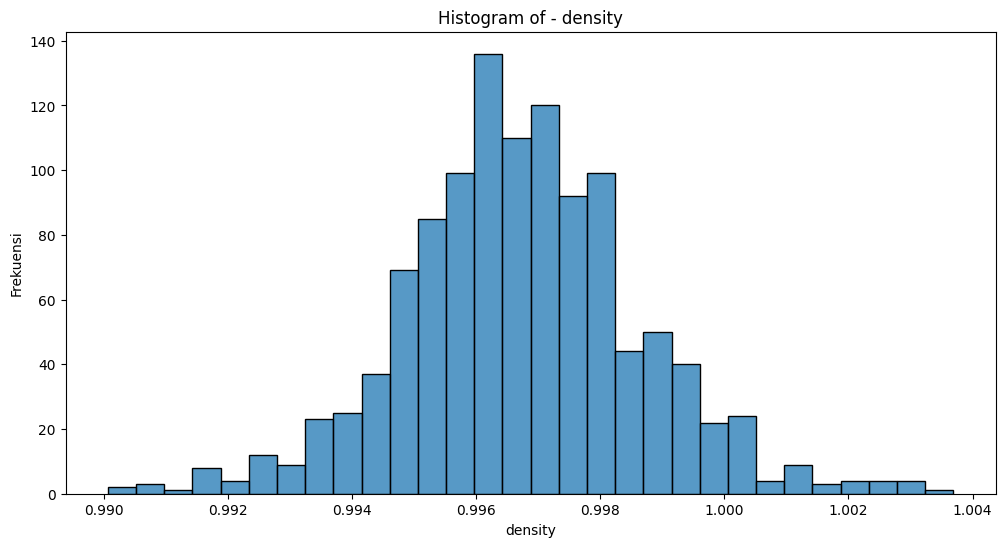

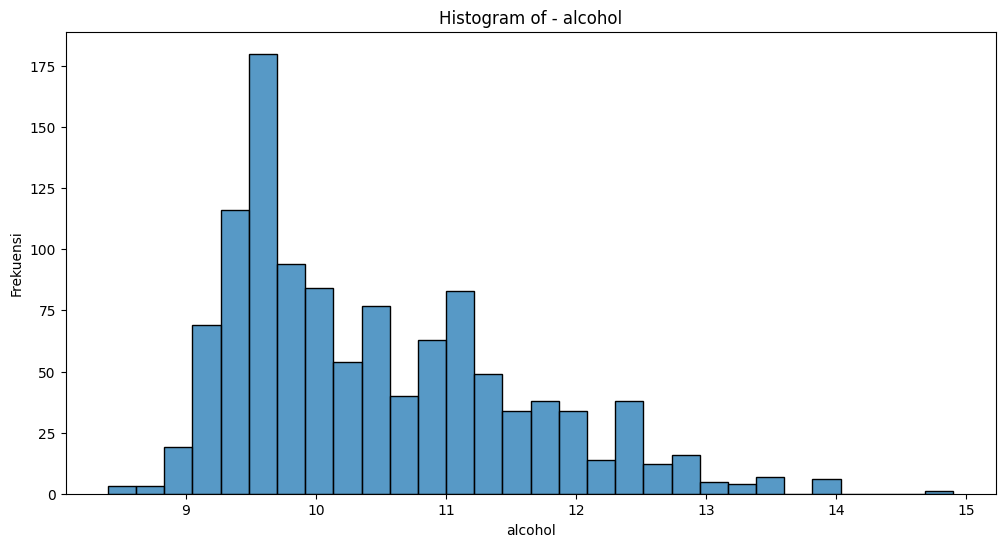

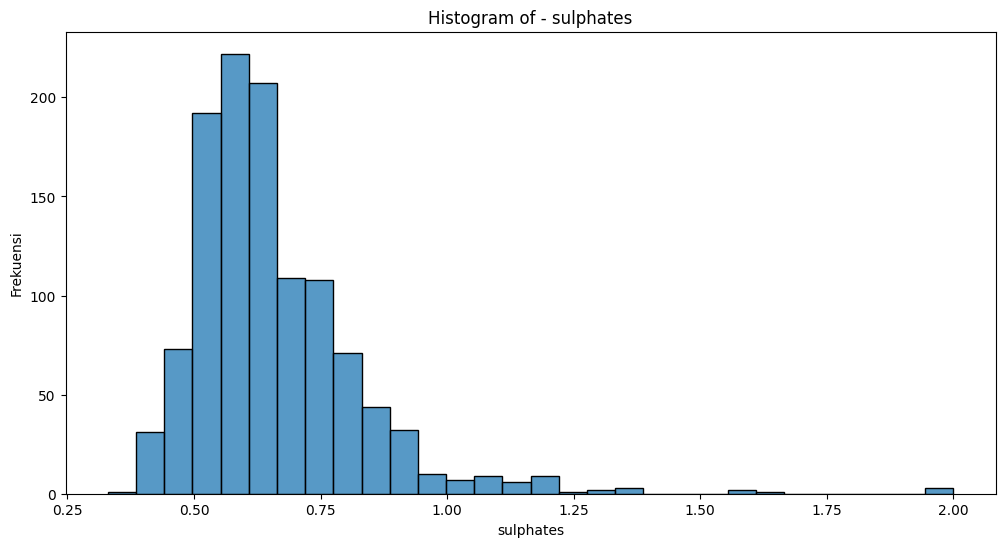

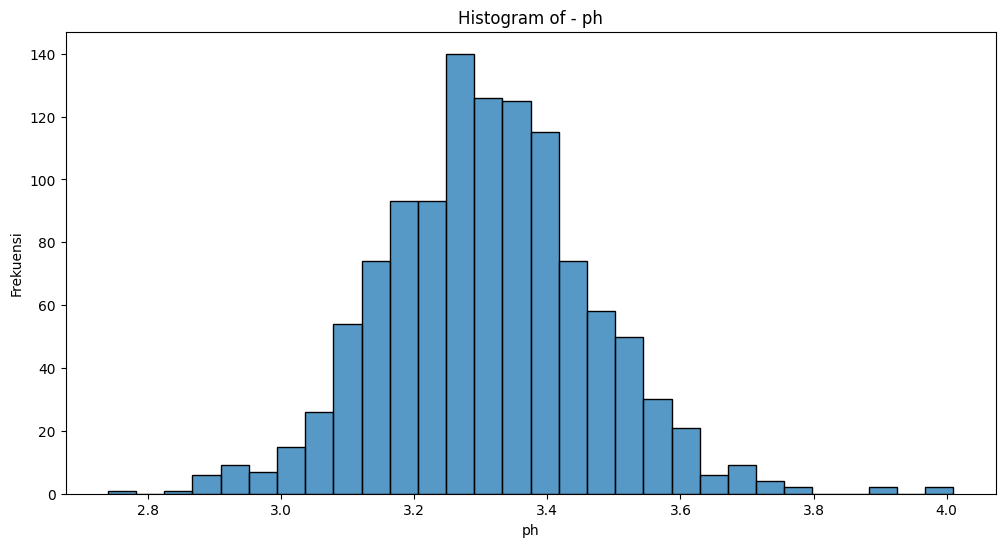

In [8]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Histogram of - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [9]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


dari hasil running program diatas, tidak ada data yg duplikat

In [16]:
fitur_columns = ['fixed_acidity', 'volatile_acidity']
X = df[fitur_columns].values
y = df['quality'].values #anotator label

In [11]:
# Outlier Handling
columns = [
    'fixed_acidity',
    'volatile_acidity',
    'citric_acid',
    'density',
    'alcohol',
    'sulphates',
    'ph'
]

for col in columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

In [17]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,fixed_acidity,volatile_acidity
count,1.001000e+03,1.001000e+03
mean,-3.975064e-16,3.762114e-16
std,1.000500e+00,1.000500e+00
min,-2.139398e+00,-2.464843e+00
25%,-7.244876e-01,-7.835431e-01
50%,-2.292691e-01,-2.939336e-03
75%,5.489314e-01,6.575715e-01
max,2.742042e+00,2.849267e+00


In [18]:
print(X_std.shape)
print(df_scalling.shape)

(1001, 2)
(1001, 2)


In [19]:
X_std

array([[-0.51225112,  1.01785019],
       [-0.22926913,  2.09868615],
       [-0.22926913,  1.37812884],
       ...,
       [-1.3611971 ,  0.41738576],
       [-1.57343359,  0.11715355],
       [-1.57343359,  0.68759475]])

In [20]:
df_scalling

,fixed_acidity,volatile_acidity
0,-0.512251,1.017850
1,-0.229269,2.098686
2,-0.229269,1.378129
3,2.176078,-1.504100
4,-0.512251,1.017850
...,...,...
996,-1.290452,-0.123032
997,-0.936724,0.537479
998,-1.361197,0.417386
999,-1.573434,0.117154


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

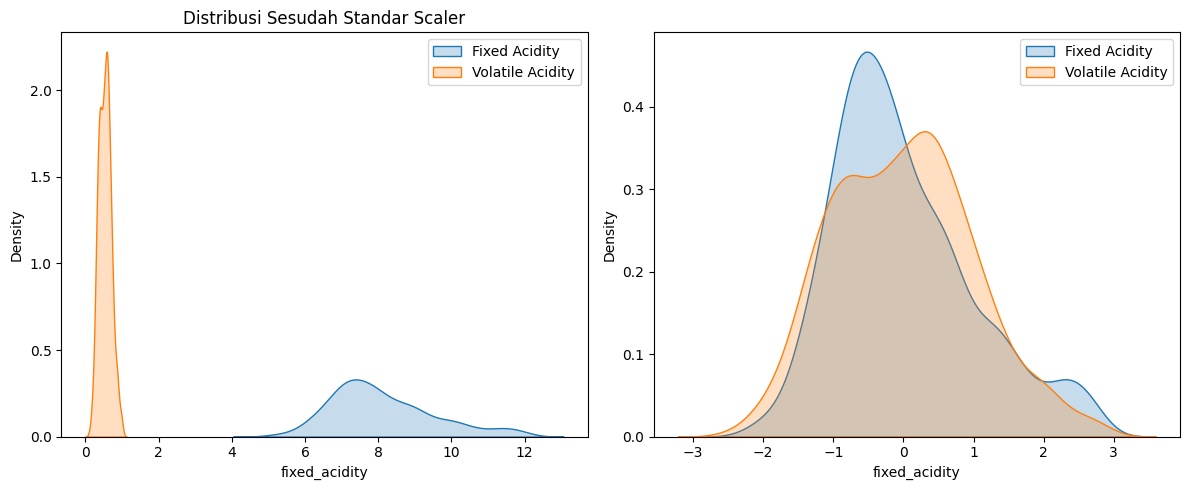

In [21]:
#cek grafik sebelum dan setelah scalling
# kita lihat distribusi dari variabel sebelum standar scaller dan setelah standar scaller

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standar Scaler (Isi dibawah ini)
# Plot distribusi sebelum Standar Scaler (Isi dibawah ini)
ax1.set_title('Distribusi Sebelum Standar Scaler')
sns.kdeplot(df['fixed_acidity'], ax=ax1, label='Fixed Acidity', fill=True)
sns.kdeplot(df['volatile_acidity'], ax=ax1, label='Volatile Acidity', fill=True)
ax1.legend()

# Plot distribusi setelah Standar Scaler (Isi dibawah ini)
ax1.set_title('Distribusi Sesudah Standar Scaler')
sns.kdeplot(df_scalling['fixed_acidity'], ax=ax2, label='Fixed Acidity', fill=True)
sns.kdeplot(df_scalling['volatile_acidity'], ax=ax2, label='Volatile Acidity', fill=True)
ax2.legend()

plt.tight_layout()
plt.show()

# Set x-labels
ax1.set_xlabel('Nilai sebelum Feature Scalling')
ax2.set_xlabel('Nilai setelah Feature Scalling')

# Menampilkan legenda
ax1.legend()
ax2.legend()

# Menampilkan plot
plt.show()

### Interpretasi dari hasil evaluasi diatas :
Secara keseluruhan, hasil StandardScaler menunjukkan bahwa proses standardisasi berhasil membuat kedua fitur memiliki skala yang lebih seimbang dengan rata-rata mendekati 0, tanpa mengubah pola distribusi aslinya


## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

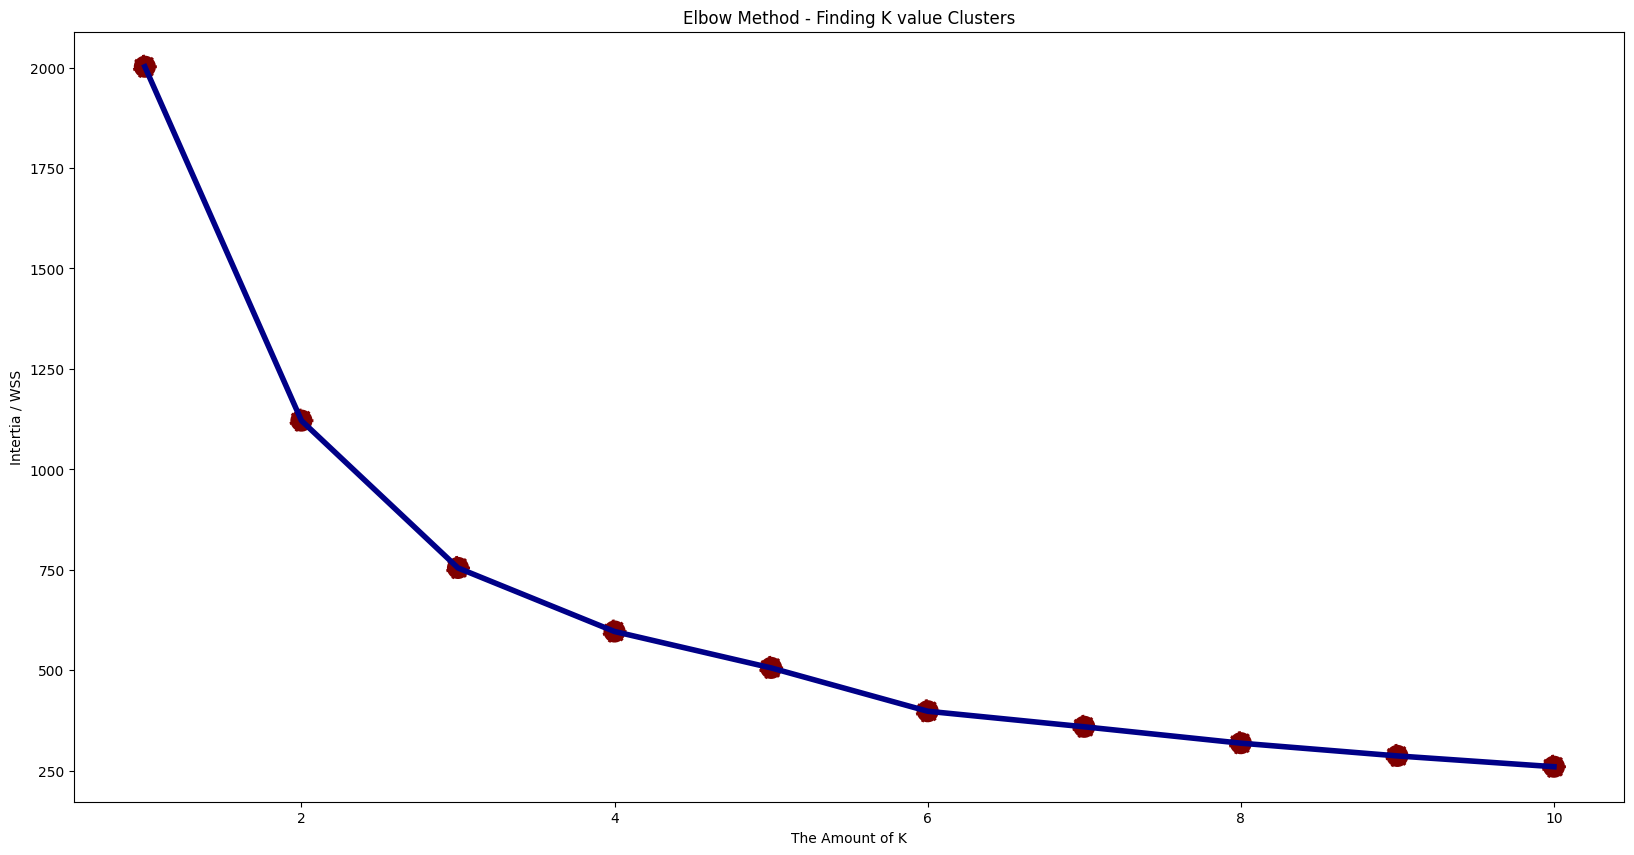

In [22]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [23]:
#Dari hasil diatas elbow nya dipilih pada angka 3,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=3, random_state=0)
kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [24]:
print(len(kmeans_elbow.labels_))
print(len(df))

1001
1001


In [25]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [26]:
df

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,id,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,2
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,2


<Axes: xlabel='fixed_acidity', ylabel='volatile_acidity'>

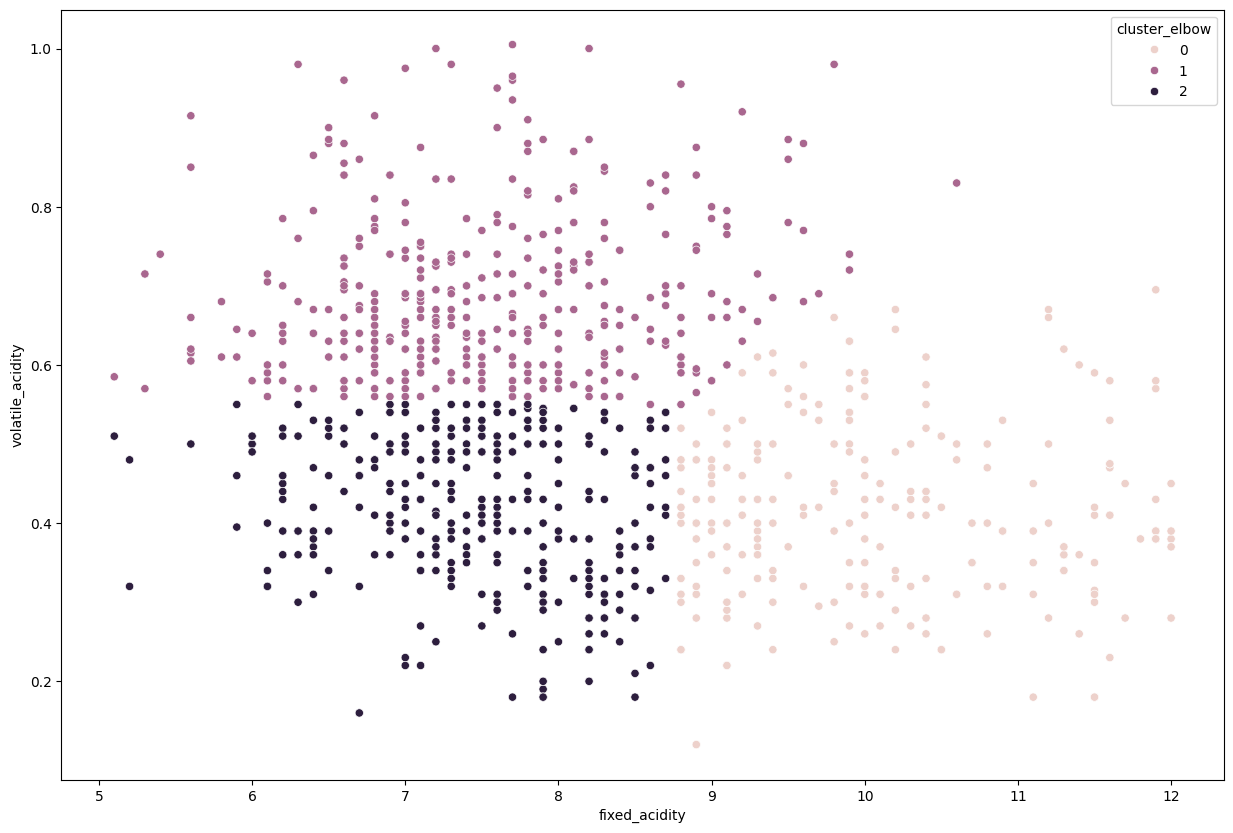

In [27]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed_acidity', y='volatile_acidity', hue='cluster_elbow')

### Bandingkan hasil dengan label anotator

<Axes: xlabel='fixed_acidity', ylabel='volatile_acidity'>

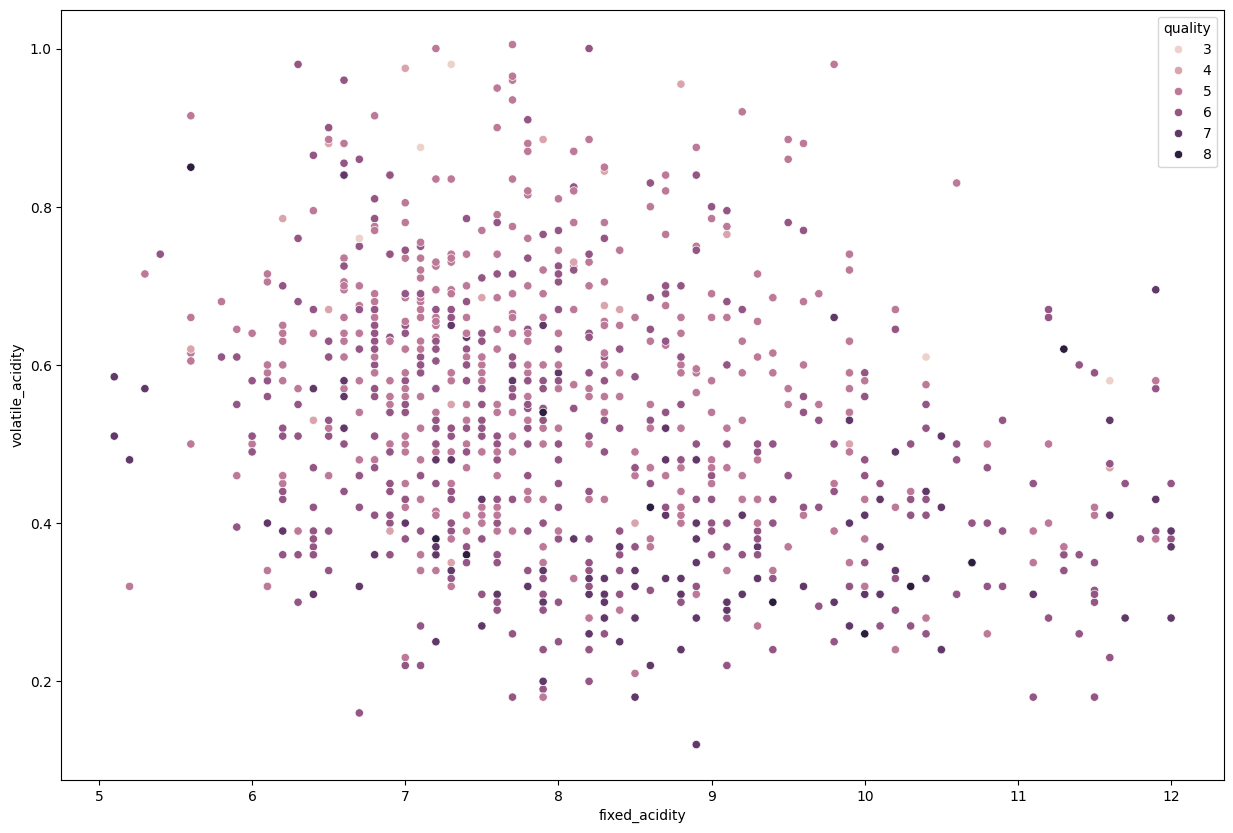

In [28]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed_acidity', y='volatile_acidity',hue='quality')

Hasil visualisasi di atas menunjukkan bahwa penggunaan metode Elbow menghasilkan jumlah cluster yang optimal sebanyak 3 cluster. Setelah dilakukan proses clustering, data terbagi ke dalam beberapa kelompok berdasarkan kemiripan nilai Fixed Acidity dan Volatile Acidity. Dengan kondisi:

1. **Cluster 0** → Kelompok wine dengan volatile acidity rendah, yang cenderung memiliki kualitas lebih baik.

2. **Cluster **1 → Kelompok wine dengan fixed acidity dan volatile acidity pada rentang sedang, serta menjadi kelompok dengan persebaran data paling dominan.

3. **Cluster 2** → Kelompok wine dengan volatile acidity tinggi, yang cenderung berkaitan dengan kualitas wine yang lebih rendah.

### 2. Via Score Plot

In [29]:
!pip install yellowbrick

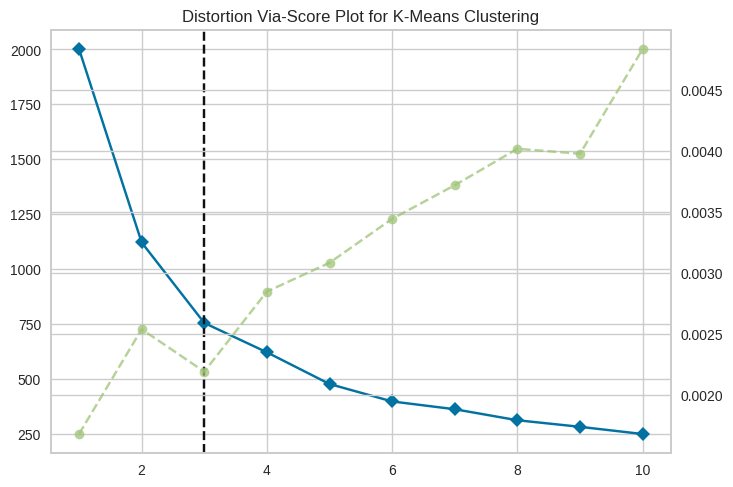

In [30]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings= True)
visualizer.fit(df_scalling.values)        # Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [31]:
# Dari hasil diatas K-nya dipilih pada angka 3,
# karena titik distorsinya bertemu pada nilai 3 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [32]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [33]:
df

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,id,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,1,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,1,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,0,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,2,2
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,2,2


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

<Axes: xlabel='fixed_acidity', ylabel='volatile_acidity'>

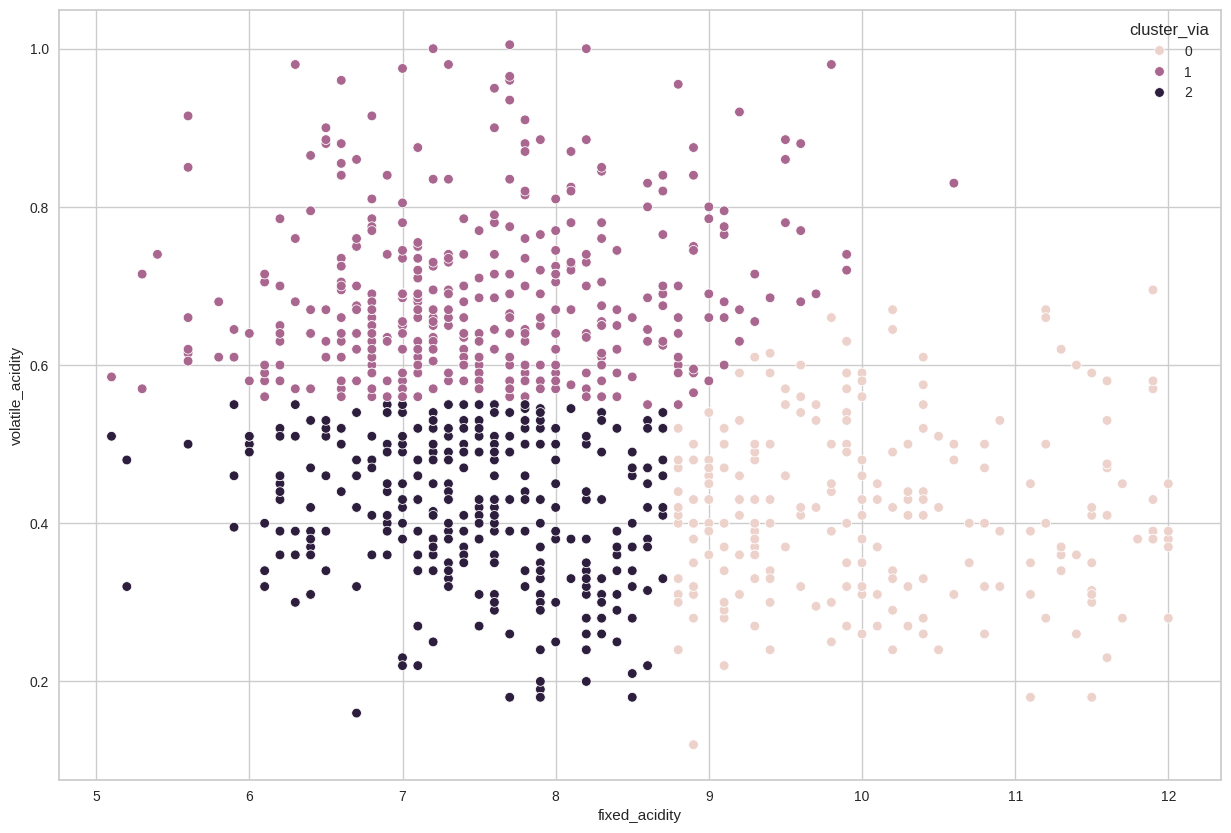

In [34]:
#Lakukan evaluasi setelah dilakukan K-Means
#Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed_acidity', y='volatile_acidity',hue='cluster_via')

### Bandingkan dengan label anotator

<Axes: xlabel='fixed_acidity', ylabel='volatile_acidity'>

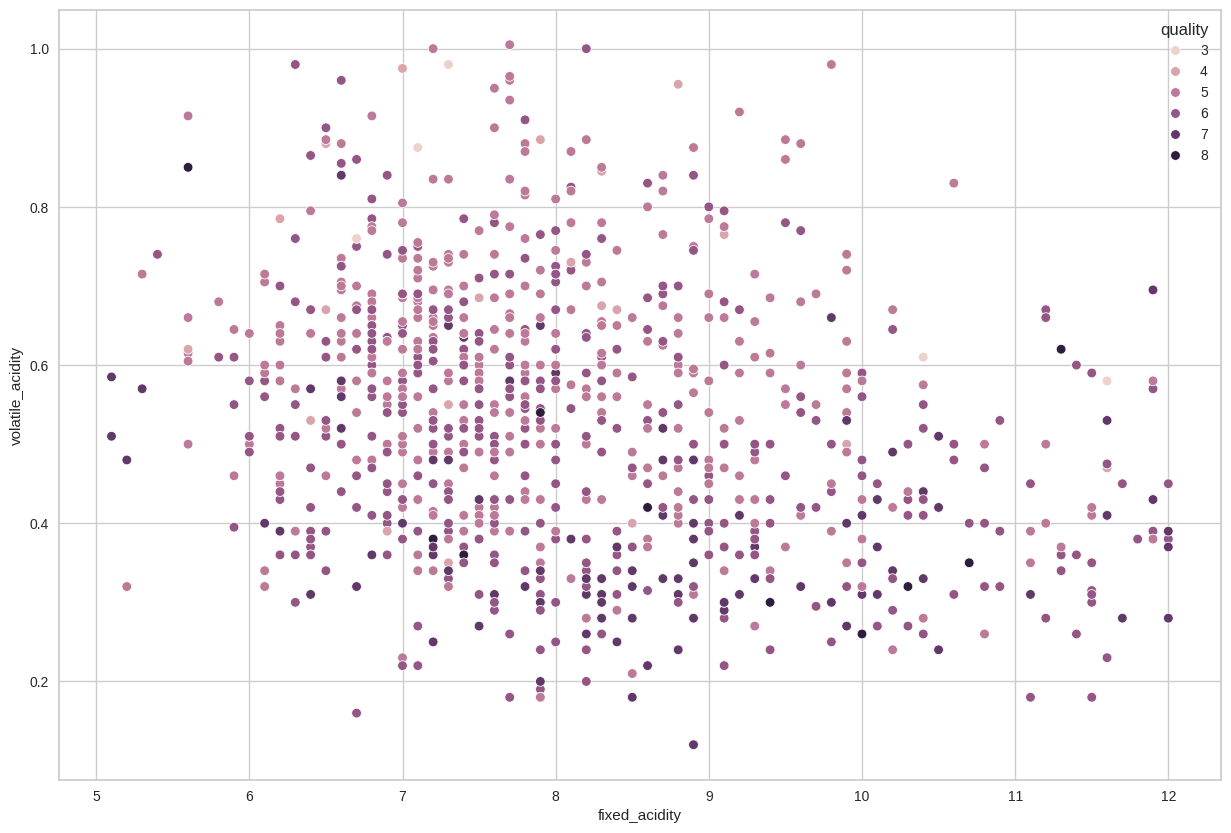

In [35]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed_acidity', y='volatile_acidity',hue='quality')

### Interpretasi dari hasil evaluasi diatas :
1. **Cluster 0** → Wine dengan Fixed Acidity tinggi dan Volatile Acidity rendah–sedang, cenderung memiliki kualitas sedang hingga baik.

2. **Cluster 1** → Wine dengan Volatile Acidity tinggi, cenderung berkaitan dengan quality lebih rendah.

3. **Cluster 2** → Wine dengan Fixed Acidity sedang dan Volatile Acidity
rendah–sedang, merupakan kelompok dengan kualitas sedang.

Hubungan dengan quality → Semakin rendah Volatile Acidity, kualitas wine cenderung lebih baik, meskipun masih ada beberapa data yang overlap antar cluster.